In [4]:
# Visualization of hierarchical clustering results
# taking genes from similar looking clusters across modules
#example: all genes from clusters that have increased expression at time points 12 and 13

In [5]:
import pandas as pd

m1= pd.read_csv('hierarchical_clustering_clusters_m1.csv', index_col=0)
m2= pd.read_csv('hierarchical_clustering_clusters_m2.csv', index_col=0)
m3= pd.read_csv('hierarchical_clustering_clusters_m3.csv', index_col=0)
m4= pd.read_csv('hierarchical_clustering_clusters_m4.csv', index_col=0) 
m5= pd.read_csv('hierarchical_clustering_clusters_m5.csv', index_col=0)
m6= pd.read_csv('hierarchical_clustering_clusters_m6.csv', index_col=0)
m7= pd.read_csv('hierarchical_clustering_clusters_m7.csv', index_col=0)

In [6]:
# cluster 9 from m1 (not that similar)
# cluster 8 from m2 (not that similar)
# cluster 1 from m3
#cluster 8 from m4
# cluster 11 from m5
# cluster 3 from m6 (too many genes, not that similar)
# cluster 1 from m7

In [7]:
# comparing clusters from m3,m5,m7
clusters_m3 = m3[m3['cluster'] == 1]
clusters_m5 = m5[m5['cluster'] == 11]
clusters_m7 = m7[m7['cluster'] == 1]

In [8]:
# cluster 9 from m1 (not that similar)
# cluster 8 from m2 (not that similar)
# cluster 1 from m3
#cluster 8 from m4
# cluster 11 from m5
# cluster 3 from m6 (too many genes, not that similar)
# cluster 1 from m7

clusters_m1 = m1[m1['cluster'] == 9]
clusters_m2 = m2[m2['cluster'] == 8]
clusters_m3 = m3[m3['cluster'] == 1]
clusters_m4 = m4[m4['cluster'] == 8]
clusters_m5 = m5[m5['cluster'] == 11]
clusters_m6 = m6[m6['cluster'] == 3]
clusters_m7 = m7[m7['cluster'] == 1]

# Combine all clusters into one DataFrame
combined_df = pd.concat([
    clusters_m1,
    clusters_m2,
    clusters_m3,
    clusters_m4,
    clusters_m5,
    clusters_m6,
    clusters_m7
])

In [9]:
# scaling expression values
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
clusters_m3_scaled = clusters_m3.copy()
clusters_m3_scaled.iloc[:, :-1] = scaler.fit_transform(clusters_m3.iloc[:, :-1].T).T
clusters_m5_scaled = clusters_m5.copy()
clusters_m5_scaled.iloc[:, :-1] = scaler.fit_transform(clusters_m5.iloc[:, :-1].T).T
clusters_m7_scaled = clusters_m7.copy()
clusters_m7_scaled.iloc[:, :-1] = scaler.fit_transform(clusters_m7.iloc[:, :-1].T).T

clusters_m4_scaled = clusters_m4.copy()
clusters_m4_scaled.iloc[:, :-1] = scaler.fit_transform(clusters_m4.iloc[:, :-1].T).T



In [10]:
clusters_m3_scaled.head()

,q1,q2,q3,q4,q5,q6,q7,q8,q9,q10,q11,q12,q13,q14,q15,q16,cluster
YPR182W,0.794062,2.169895,-0.132837,-0.411301,0.333308,-0.243466,0.699890,0.179484,-0.949663,-0.590714,-1.647415,-1.826599,1.074282,0.819896,-0.690331,0.421508,1
YGR063C,-0.120215,0.712778,-0.482418,-0.790905,0.124555,0.235756,0.609244,1.681595,-0.423391,-0.221594,-0.760687,-1.919084,1.508763,1.694615,-0.894468,-0.954543,1
YPL098C,-1.888845,-1.429792,1.199964,0.425317,0.449192,0.510653,1.339880,0.629620,-0.955104,-1.639158,0.407038,0.297261,1.122587,-0.129522,-0.849743,0.510653,1
YLR402W,-0.784058,-0.705261,-0.081639,-0.492938,0.195747,0.125019,1.224567,0.645144,-1.134833,-0.682104,0.346439,0.230216,1.705951,2.038117,-0.984467,-1.645901,1
YLR110C,0.389833,1.082087,-0.292072,-0.780922,1.068684,1.595806,-1.078625,-1.192011,-1.204722,-0.802147,-1.162973,-0.025507,1.618490,1.059848,-0.627886,0.352116,1


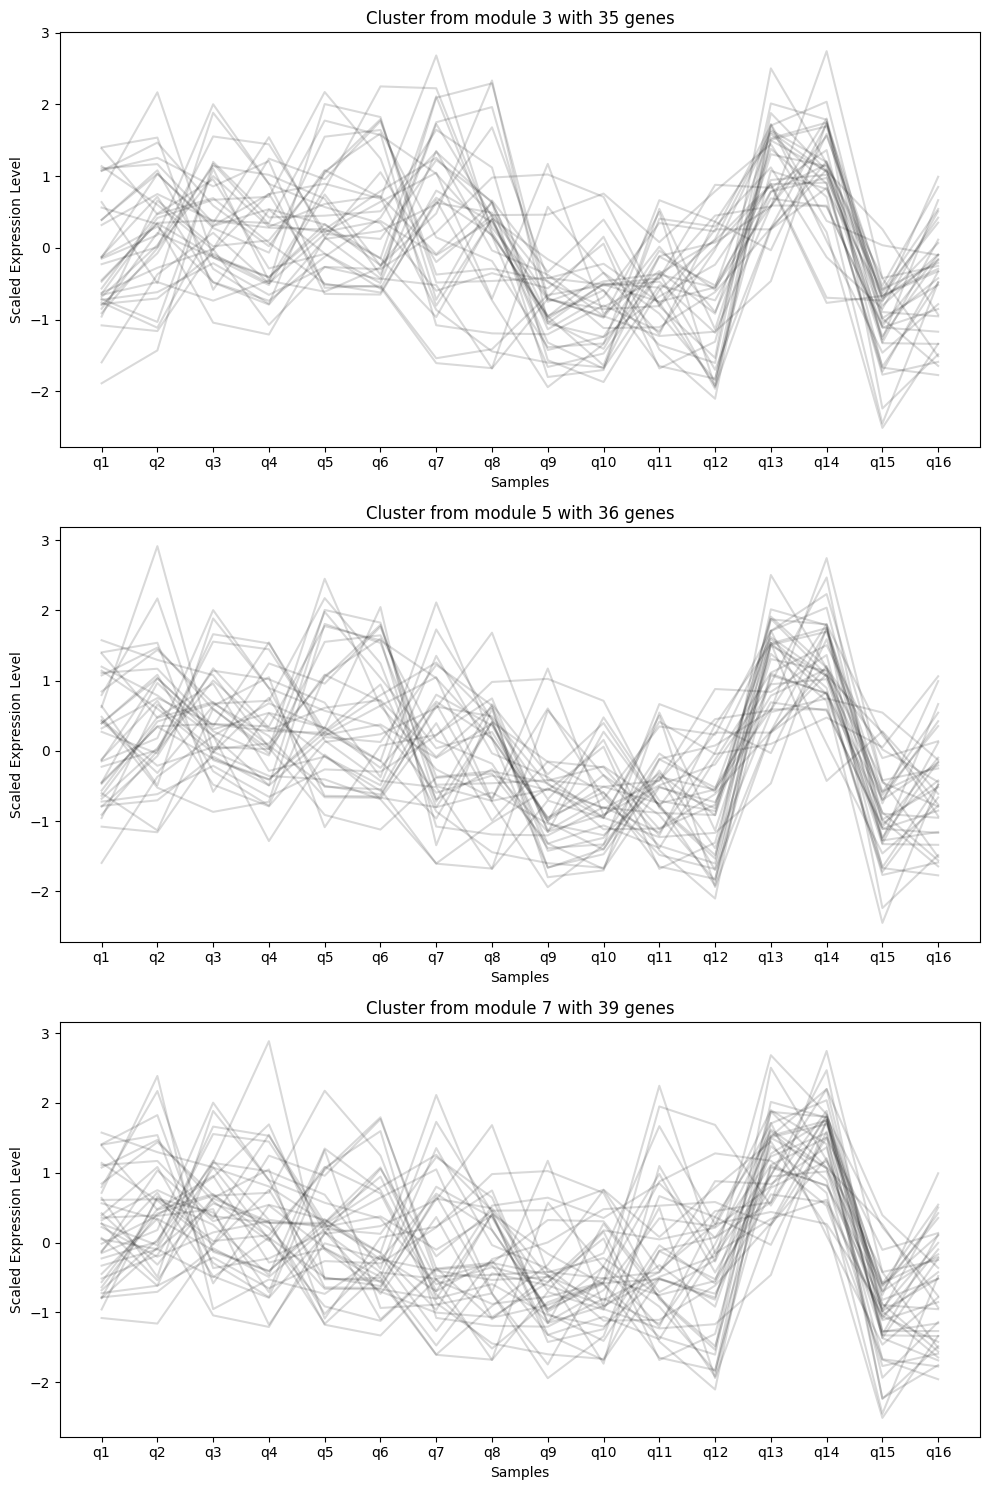

In [11]:
# plot each cluster in a subplot
import matplotlib.pyplot as plt
fig, axs = plt.subplots(3, 1, figsize=(10, 15))
for i, (cluster, ax) in enumerate(zip([clusters_m3_scaled, clusters_m5_scaled, clusters_m7_scaled], axs)):
    for index, row in cluster.iterrows():
        ax.plot(row[:-1], alpha=0.15, color='black')
    ax.set_title(f'Cluster from module {[3,5,7][i]} with {len(cluster)} genes')
    ax.set_xlabel('Samples')
    ax.set_ylabel('Scaled Expression Level')
plt.tight_layout()
plt.show()

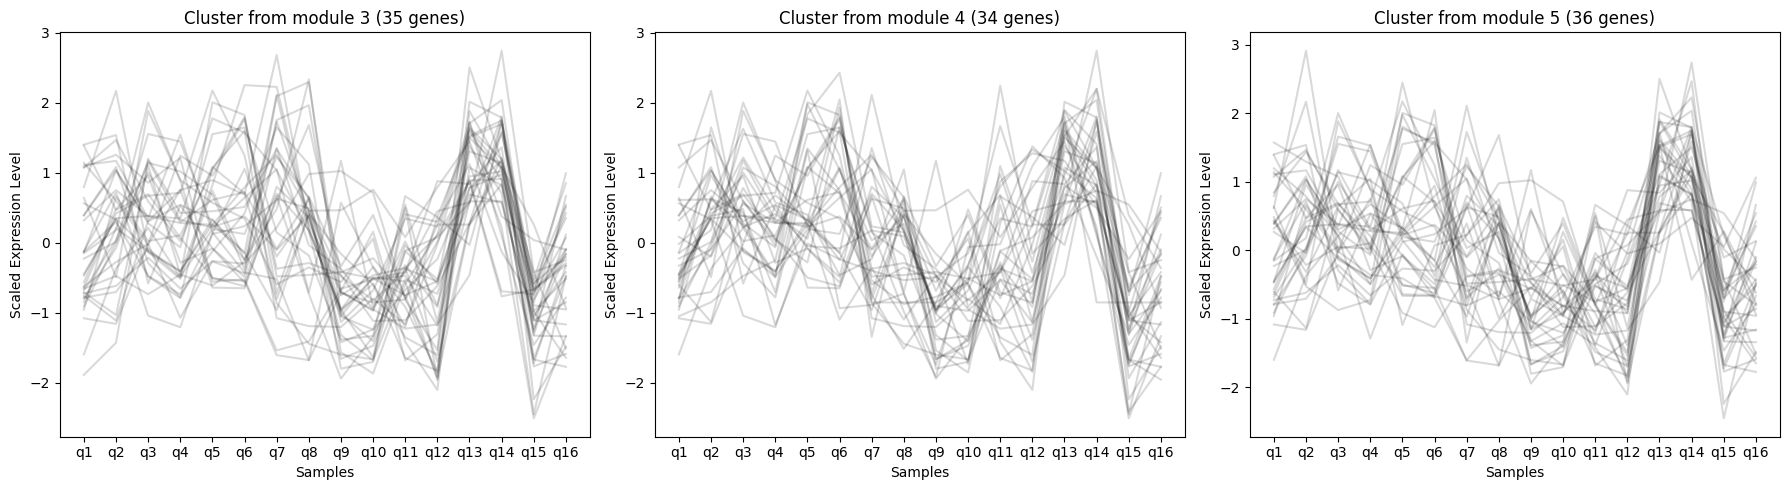

In [12]:
import matplotlib.pyplot as plt

# Plot each cluster in a subplot side by side
fig, axs = plt.subplots(1, 3, figsize=(18, 5))  # 1 row, 3 columns

clusters_list = [clusters_m3_scaled, clusters_m4_scaled, clusters_m5_scaled]  # your clusters
modules = [3, 4, 5]  # corresponding module numbers

for i, (cluster, ax) in enumerate(zip(clusters_list, axs)):
    for index, row in cluster.iterrows():
        ax.plot(row[:-1], alpha=0.15, color='black')  # plot each gene with low opacity
    ax.set_title(f'Cluster from module {modules[i]} ({len(cluster)} genes)')
    ax.set_xlabel('Samples')
    ax.set_ylabel('Scaled Expression Level')

plt.tight_layout()
plt.show()


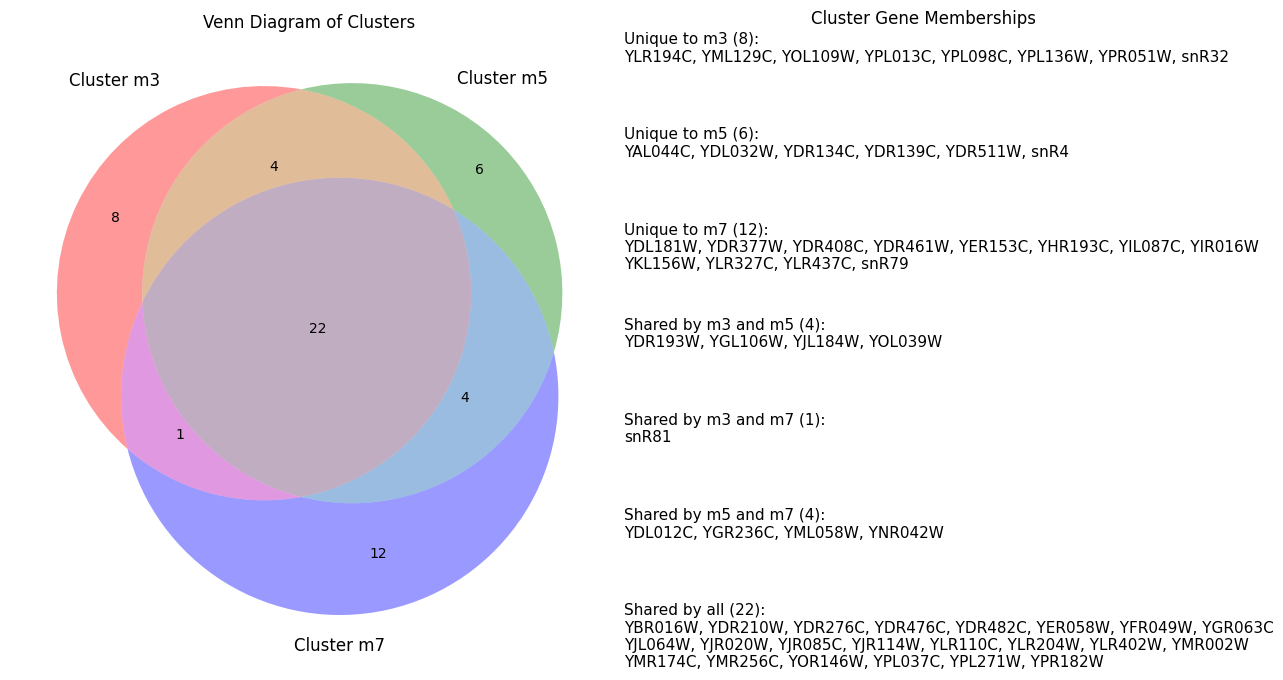

In [13]:
from matplotlib_venn import venn3
import matplotlib.pyplot as plt

# build sets of gene names from indices
set1 = set(clusters_m3.index)
set2 = set(clusters_m5.index)
set3 = set(clusters_m7.index)

# helper to wrap gene names
def wrap_genes(genes, n=8):
    genes = sorted(list(genes))
    return "\n".join([", ".join(genes[i:i+n]) for i in range(0, len(genes), n)])

# subsets
unique_m3 = set1 - set2 - set3
unique_m5 = set2 - set1 - set3
unique_m7 = set3 - set1 - set2
shared_all = set1 & set2 & set3
shared_m3_m5 = (set1 & set2) - set3
shared_m3_m7 = (set1 & set3) - set2
shared_m5_m7 = (set2 & set3) - set1

legend_text = [
    f"Unique to m3 ({len(unique_m3)}):\n{wrap_genes(unique_m3)}",
    f"Unique to m5 ({len(unique_m5)}):\n{wrap_genes(unique_m5)}",
    f"Unique to m7 ({len(unique_m7)}):\n{wrap_genes(unique_m7)}",
    f"Shared by m3 and m5 ({len(shared_m3_m5)}):\n{wrap_genes(shared_m3_m5)}",
    f"Shared by m3 and m7 ({len(shared_m3_m7)}):\n{wrap_genes(shared_m3_m7)}",
    f"Shared by m5 and m7 ({len(shared_m5_m7)}):\n{wrap_genes(shared_m5_m7)}",
    f"Shared by all ({len(shared_all)}):\n{wrap_genes(shared_all)}"
]

# --- Make subplots ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# subplot 1: venn diagram
venn3([set1, set2, set3], ('Cluster m3', 'Cluster m5', 'Cluster m7'), ax=ax1)
ax1.set_title("Venn Diagram of Clusters")

# subplot 2: legend text
ax2.axis("off")
y = 1
for block in legend_text:
    ax2.text(0, y, block, fontsize=11, va="top")
    y -= 0.15 #+ 0.02 * block.count("\n")  # adjust spacing
ax2.set_title("Cluster Gene Memberships")

plt.tight_layout()
plt.show()


In [14]:
shared_all

{'YBR016W',
 'YDR210W',
 'YDR276C',
 'YDR476C',
 'YDR482C',
 'YER058W',
 'YFR049W',
 'YGR063C',
 'YJL064W',
 'YJR020W',
 'YJR085C',
 'YJR114W',
 'YLR110C',
 'YLR204W',
 'YLR402W',
 'YMR002W',
 'YMR174C',
 'YMR256C',
 'YOR146W',
 'YPL037C',
 'YPL271W',
 'YPR182W'}

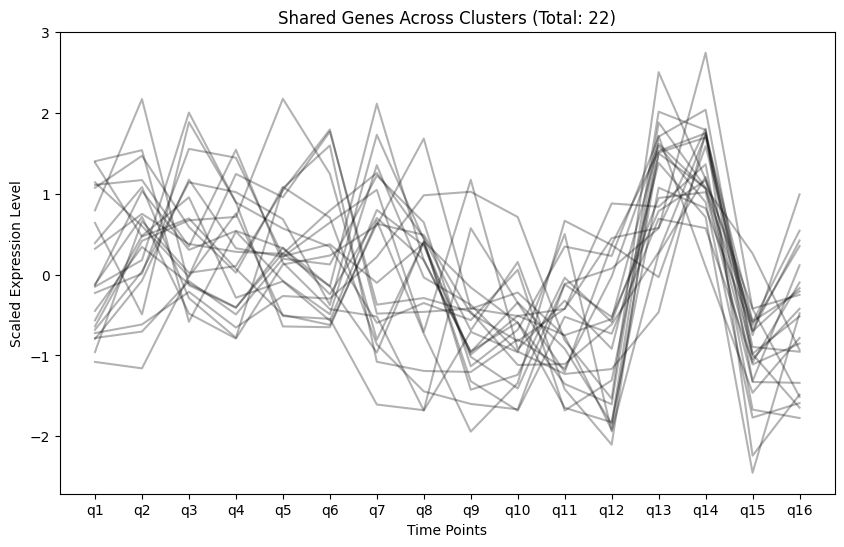

In [15]:
# plot values from shared_all (from the scaled df) in a line plot
fig, ax = plt.subplots(figsize=(10, 6))
for gene in shared_all:
    ax.plot(clusters_m3_scaled.loc[gene][:-1], alpha=0.3, color='black')
ax.set_title(f'Shared Genes Across Clusters (Total: {len(shared_all)})')
ax.set_xlabel('Time Points')
ax.set_ylabel('Scaled Expression Level')
plt.show()

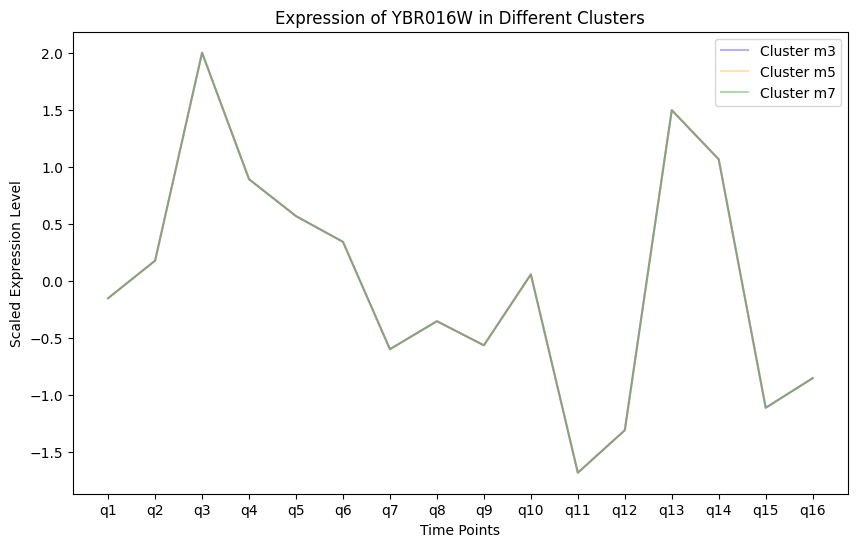

In [16]:
# picking one gene and plotting it for different clusters: YBR016W
gene = 'YBR016W'
fig, ax = plt.subplots(figsize=(10, 6))
if gene in clusters_m3_scaled.index:
    ax.plot(clusters_m3_scaled.loc[gene][:-1], label='Cluster m3', color='blue', alpha=0.3)
if gene in clusters_m5_scaled.index:
    ax.plot(clusters_m5_scaled.loc[gene][:-1], label='Cluster m5', color='orange',alpha=0.3)
if gene in clusters_m7_scaled.index:
    ax.plot(clusters_m7_scaled.loc[gene][:-1], label='Cluster m7', color='green', alpha=0.3)
ax.set_title(f'Expression of {gene} in Different Clusters')
ax.set_xlabel('Time Points')
ax.set_ylabel('Scaled Expression Level')
ax.legend()
plt.show()

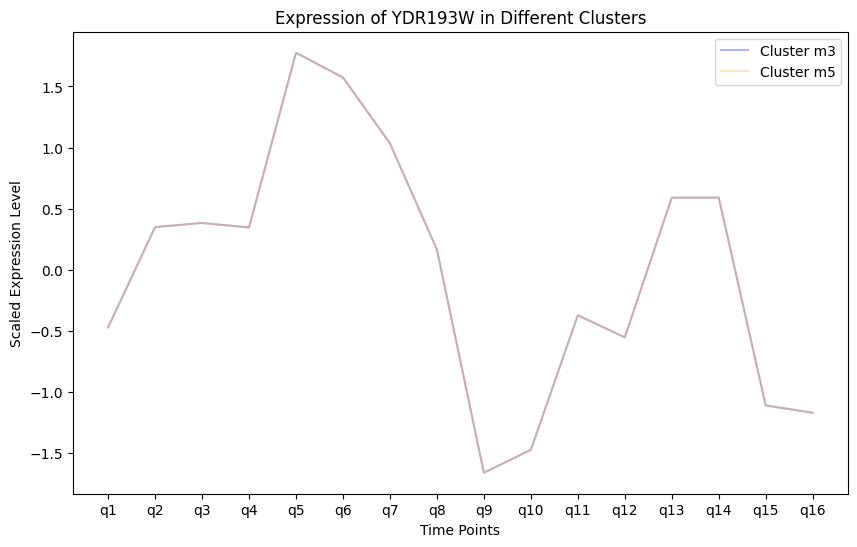

In [17]:
#gene from m3 and m5
gene = 'YDR193W'
fig, ax = plt.subplots(figsize=(10, 6))
if gene in clusters_m3_scaled.index:
    ax.plot(clusters_m3_scaled.loc[gene][:-1], label='Cluster m3', color='blue', alpha=0.3)
if gene in clusters_m5_scaled.index:
    ax.plot(clusters_m5_scaled.loc[gene][:-1], label='Cluster m5', color='orange',alpha=0.3)
#if gene in clusters_m7_scaled.index:
    #ax.plot(clusters_m7_scaled.loc[gene][:-1], label='Cluster m7', color='green', alpha=0.3)
ax.set_title(f'Expression of {gene} in Different Clusters')
ax.set_xlabel('Time Points')
ax.set_ylabel('Scaled Expression Level')
ax.legend()
plt.show()

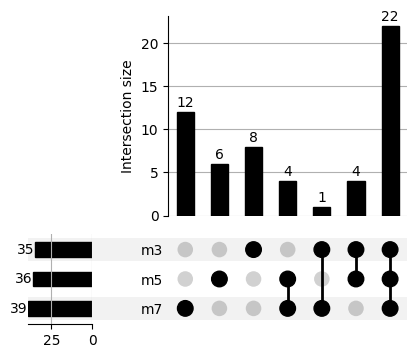

In [18]:
from upsetplot import UpSet, from_contents
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore", category=FutureWarning, module="upsetplot")

clusters = {
    "m3": set(clusters_m3.index),
    "m5": set(clusters_m5.index),
    "m7": set(clusters_m7.index),

}

data = from_contents(clusters)
UpSet(data, subset_size='count', show_counts=True).plot()
plt.show()


In [19]:
# cluster 9 from m1 (not that similar)
# cluster 8 from m2 (not that similar)
# cluster 1 from m3
#cluster 8 from m4
# cluster 11 from m5
# cluster 3 from m6 (too many genes, not that similar)
# cluster 1 from m7

clusters_m1 = m1[m1['cluster'] == 9]
clusters_m2 = m2[m2['cluster'] == 8]
clusters_m3 = m3[m3['cluster'] == 1]
clusters_m4 = m4[m4['cluster'] == 8]
clusters_m5 = m5[m5['cluster'] == 11]
clusters_m6 = m6[m6['cluster'] == 3]
clusters_m7 = m7[m7['cluster'] == 1]

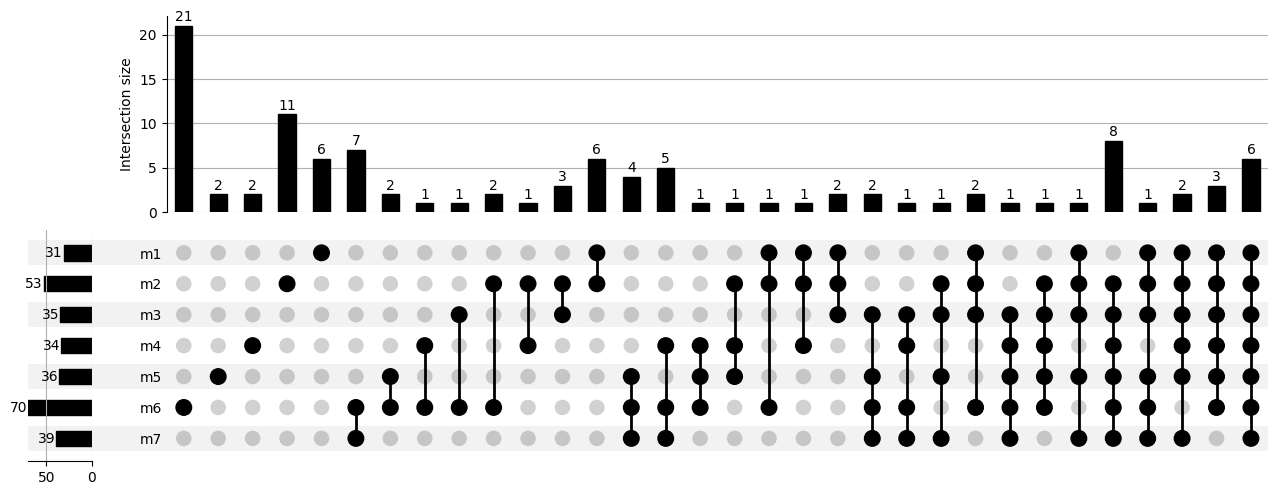

In [20]:
# upset plot for all 7 clusters
from upsetplot import UpSet, from_contents
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore", category=FutureWarning, module="upsetplot")

clusters = {
    "m7": set(clusters_m7.index),
    "m6": set(clusters_m6.index),
    "m5": set(clusters_m5.index),
    "m4": set(clusters_m4.index),
    "m3": set(clusters_m3.index),
    "m2": set(clusters_m2.index),
    "m1": set(clusters_m1.index),
}       

data = from_contents(clusters)
UpSet(data, subset_size='count', show_counts=True, sort_categories_by=None).plot()
plt.show()



In [21]:
clusters = [
    set(clusters_m1.index),
    set(clusters_m2.index),
    set(clusters_m3.index),
    set(clusters_m4.index),
    set(clusters_m5.index),
    set(clusters_m6.index),
    set(clusters_m7.index),
]

# now compute intersection
shared_genes = set.intersection(*clusters)

print(f"Number of genes shared by all modules: {len(shared_genes)}")
print("Genes:", shared_genes)


Number of genes shared by all modules: 6
Genes: {'YLR110C', 'YLR402W', 'YMR002W', 'YJR085C', 'YFR049W', 'YMR256C'}


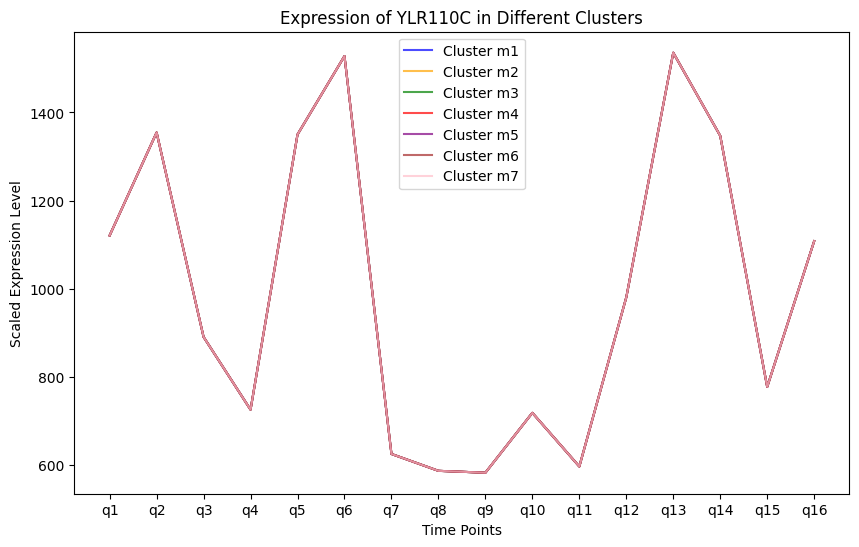

In [22]:
# plot YLR110C for each cluster

gene = 'YLR110C'
# ---
fig, ax = plt.subplots(figsize=(10, 6))
for i, (cluster, color) in enumerate(zip([clusters_m1, clusters_m2, clusters_m3, clusters_m4, clusters_m5, clusters_m6, clusters_m7],
                                       ['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink'])):
    if gene in cluster.index:
        ax.plot(cluster.loc[gene][:-1], label=f'Cluster m{i+1}', color=color, alpha=0.7)
ax.set_title(f'Expression of {gene} in Different Clusters')
ax.set_xlabel('Time Points')
ax.set_ylabel('Scaled Expression Level')
ax.legend()
plt.show()

In [23]:
# make a df of expression profiles of YLR402W in all modules
gene = 'YLR402W'
gene_profiles = {}
for i, cluster in enumerate([clusters_m1, clusters_m2, clusters_m3, clusters_m4, clusters_m5, clusters_m6, clusters_m7]):
    if gene in cluster.index:
        gene_profiles[f'm{i+1}'] = cluster.loc[gene][:-1]
gene_profiles_df = pd.DataFrame(gene_profiles)
gene_profiles= gene_profiles_df.T
gene_profiles.head(7)

,q1,q2,q3,q4,q5,q6,q7,q8,q9,q10,q11,q12,q13,q14,q15,q16
m1,2631.01,2710.7,3341.39,2925.43,3621.92,3550.39,4662.4,4076.41,2276.26,2734.12,3774.32,3656.78,5149.24,5485.17,2428.33,1759.4
m2,2631.01,2710.7,3341.39,2925.43,3621.92,3550.39,4662.4,4076.41,2276.26,2734.12,3774.32,3656.78,5149.24,5485.17,2428.33,1759.4
m3,2631.01,2710.7,3341.39,2925.43,3621.92,3550.39,4662.4,4076.41,2276.26,2734.12,3774.32,3656.78,5149.24,5485.17,2428.33,1759.4
m4,2631.01,2710.7,3341.39,2925.43,3621.92,3550.39,4662.4,4076.41,2276.26,2734.12,3774.32,3656.78,5149.24,5485.17,2428.33,1759.4
m5,2631.01,2710.7,3341.39,2925.43,3621.92,3550.39,4662.4,4076.41,2276.26,2734.12,3774.32,3656.78,5149.24,5485.17,2428.33,1759.4
m6,2631.01,2710.7,3341.39,2925.43,3621.92,3550.39,4662.4,4076.41,2276.26,2734.12,3774.32,3656.78,5149.24,5485.17,2428.33,1759.4
m7,2631.01,2710.7,3341.39,2925.43,3621.92,3550.39,4662.4,4076.41,2276.26,2734.12,3774.32,3656.78,5149.24,5485.17,2428.33,1759.4


# Gene regulation data

In [24]:
df_reg = pd.read_csv('Yeast_gene_reg_clusters.csv', index_col=0)
df_reg.head()

,weight_1,weight_2,weight_3,weight_4,weight_5,weight_6,weight_7,cluster
Reg,,,,,,,,
YPR182W_YOL039W,0.010540,0.0,0.0,0.0,0.0108,0.0,0.000000,4
snR77_YBR252W,0.010698,0.0,0.0,0.0,0.0000,0.0,0.000000,5
snR77_YLR062C,0.011013,0.0,0.0,0.0,0.0000,0.0,0.000000,5
snR77_YGR063C,0.012532,0.0,0.0,0.0,0.0000,0.0,0.000000,5
snR77_YLR402W,0.040704,0.0,0.0,0.0,0.0000,0.0,0.029929,0


In [25]:
# find genes that are only common between m2 and m6 and no other modules
common_genes_m2_m6 = set(clusters_m2.index).intersection(set(clusters_m6.index))
common_genes_m2_m6 = list(common_genes_m2_m6)
# Correct way: filter out genes that appear in any other cluster
exclusive_genes_m2_m6 = [
    gene for gene in common_genes_m2_m6
    if gene not in clusters_m1.index
    and gene not in clusters_m3.index
    and gene not in clusters_m4.index
    and gene not in clusters_m5.index
    and gene not in clusters_m7.index
]

exclusive_genes_m2_m6


['YFL067W', 'YPL234C']

In [26]:
#show values of exclusive_genes_m2_m6 in clusters_m2 and clusters_m6 in a df
# make a df of expression profiles of YLR402W in all modules
gene = 'YPL234C'
gene_profiles = {}
for i, cluster in enumerate([clusters_m2, clusters_m6]):
    if gene in cluster.index:
        gene_profiles[f'm{i+1}'] = cluster.loc[gene][:-1]
gene_profiles_df = pd.DataFrame(gene_profiles)
gene_profiles= gene_profiles_df.T
gene_profiles.head(7)


,q1,q2,q3,q4,q5,q6,q7,q8,q9,q10,q11,q12,q13,q14,q15,q16
m1,626.014,719.026,842.604,767.457,754.382,708.809,698.934,590.402,459.877,478.18,563.03,539.618,761.389,839.406,647.667,461.56
m2,626.014,719.026,842.604,767.457,754.382,708.809,698.934,590.402,459.877,478.18,563.03,539.618,761.389,839.406,647.667,461.56


In [27]:
from itertools import combinations

# Step 1: Define your sets
all_sets = {
    'm1': set(clusters_m1.index),
    'm2': set(clusters_m2.index),
    'm3': set(clusters_m3.index),
    'm4': set(clusters_m4.index),
    'm5': set(clusters_m5.index),
    'm6': set(clusters_m6.index),
    'm7': set(clusters_m7.index)
}

# Step 2: Extract all exclusive intersections
exclusive_intersections = {}

set_names = list(all_sets.keys())

for r in range(1, len(set_names) + 1):
    for combo in combinations(set_names, r):
        # Intersect selected sets
        shared = set.intersection(*[all_sets[name] for name in combo])
        
        # Subtract genes from all other sets
        other_sets = [name for name in set_names if name not in combo]
        for name in other_sets:
            shared -= all_sets[name]
        
        # Save result
        if shared:
            exclusive_intersections[combo] = shared


In [28]:
# Reset index if needed
#combined_df.reset_index(inplace=True)
#combined_df.rename(columns={'index': 'gene'}, inplace=True)

# Preview
print(combined_df.shape)
combined_df.head()

(298, 17)


,q1,q2,q3,q4,q5,q6,q7,q8,q9,q10,q11,q12,q13,q14,q15,q16,cluster
YDL130W,985.471,1148.91,938.661,929.943,976.90,951.154,988.064,1187.84,715.265,579.420,988.064,944.473,932.51,774.952,849.118,590.353,9
YGR063C,971.091,1223.16,861.486,768.136,1045.16,1078.810,1191.830,1516.33,879.348,940.413,777.280,426.742,1464.03,1520.270,736.797,718.618,9
snR77,4197.160,1549.53,2665.190,6271.050,5646.60,5743.950,7614.840,0.00,2692.120,0.000,0.000,0.000,0.00,3919.400,2082.180,0.000,9
YPL098C,945.785,1035.19,1547.360,1396.490,1401.14,1413.110,1574.610,1436.28,1127.640,994.414,1392.930,1371.550,1532.29,1288.430,1148.160,1413.110,9
YLR402W,2631.010,2710.70,3341.390,2925.430,3621.92,3550.390,4662.400,4076.41,2276.260,2734.120,3774.320,3656.780,5149.24,5485.170,2428.330,1759.400,9


In [29]:
from matplotlib.pyplot import sca
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_df = scaler.fit_transform(combined_df.iloc[:, :-1].T).T
scaled_df = pd.DataFrame(scaled_df, index=combined_df.index, columns=combined_df.columns[:-1])
scaled_df['cluster'] = combined_df['cluster']
scaled_df.head()

,q1,q2,q3,q4,q5,q6,q7,q8,q9,q10,q11,q12,q13,q14,q15,q16,cluster
YDL130W,0.489214,1.483671,0.204395,0.151350,0.437063,0.280410,0.504992,1.720543,-1.154874,-1.981433,0.504992,0.239759,0.166969,-0.791704,-0.340436,-1.914911,9
YGR063C,-0.120215,0.712778,-0.482418,-0.790905,0.124555,0.235756,0.609244,1.681595,-0.423391,-0.221594,-0.760687,-1.919084,1.508763,1.694615,-0.894468,-0.954543,9
snR77,0.607318,-0.431221,0.006399,1.420807,1.175865,1.214050,1.947911,-1.039028,0.016962,-1.039028,-1.039028,-1.039028,-1.039028,0.498366,-0.222288,-1.039028,9
YPL098C,-1.888845,-1.429792,1.199964,0.425317,0.449192,0.510653,1.339880,0.629620,-0.955104,-1.639158,0.407038,0.297261,1.122587,-0.129522,-0.849743,0.510653,9
YLR402W,-0.784058,-0.705261,-0.081639,-0.492938,0.195747,0.125019,1.224567,0.645144,-1.134833,-0.682104,0.346439,0.230216,1.705951,2.038117,-0.984467,-1.645901,9
